```{note}
I'm trying something new here and submitting the whole assignment as a single Jupyter notebook. Let me know if this is less desirable and I can switch things up
```

*I'm trying something new here and submitting the whole assignment as a single Jupyter notebook. Let me know if this is less desirable and I can switch things up*

***

In [38]:
import numpy as np
from scipy.linalg import eigh
import pandas as pd
import matplotlib.pyplot as plt

### Problem 1

Three such points are:
>$x_1=(3,0),\;x_2=(0,0),\;x_3=(0,4)$

To see that their distances are as desired:

In [7]:
#define the points
x_1 = np.array([3,0])
x_2 = np.array([0,0])
x_3 = np.array([0,4])

In [4]:
# square of the norm of x_1-x_2:
np.linalg.norm(x_1-x_2)**2

9.0

In [5]:
# square of the norm of x_1-x_3:
np.linalg.norm(x_1-x_3)**2

25.0

In [6]:
# square of the norm of x_3-x_2:
np.linalg.norm(x_3-x_2)**2

16.0

***

### Problem 2

We first define the distance matrix $D$ associated with these three points. Note that entry $d_{ij}$ is the *square* of the distance between points $x_i$ and $x_j$.

In [9]:
D=np.array([[0,1,6],[1,0,1],[6,1,0]])
D

array([[0, 1, 6],
       [1, 0, 1],
       [6, 1, 0]])

We now find matrix $G$

In [11]:
#Solve for G
n = D.shape[0]
G = 0.5*(np.ones((n,1)).dot(D[[0],:]) + D[:,[0]].dot(np.ones((1,n))) - D)
G

array([[0., 0., 0.],
       [0., 1., 3.],
       [0., 3., 6.]])

We now check to see if $G$ has negative eigenvalues. Recall that, as $G$ is symmetric, it will be positive semidefinite if and only if it has nonnegative eigenvalues.

In [15]:
#find the eigenvalues and eigenvectors of G
diag,Q = eigh(G)
diag

array([-0.40512484,  0.        ,  7.40512484])

In [17]:
# does G have a negative eigenvalue?
diag[0] < 0

True

So $G$ is not positive semidefinite. We now show that these points violate the triangle inequality:

$$
\sqrt{6} = \|x_1-x_3\|_2 = \|x_1 - x_2 + x_2 -x_3\|_2 \leq \|x_1 - x_2 \|_2 + \|x_2 - x_3 \|_2 = 1 + 1 = 2
$$

Obviously, $\sqrt{6}$ is not less than or equal to $2$, so these points violate the triangle inequality.

***

### Problem 3

We first define matrix $D$, as in problem 2, then find $G$ from that.

In [20]:
# It's a little faster to define D as the difference between the all-ones matrix and the identity matrix
D = np.ones((4,4))-np.diag(np.ones(4))
D

array([[0., 1., 1., 1.],
       [1., 0., 1., 1.],
       [1., 1., 0., 1.],
       [1., 1., 1., 0.]])

In [21]:
#Solve for G
n = D.shape[0]
G = 0.5*(np.ones((n,1)).dot(D[[0],:]) + D[:,[0]].dot(np.ones((1,n))) - D)
G

array([[0. , 0. , 0. , 0. ],
       [0. , 1. , 0.5, 0.5],
       [0. , 0.5, 1. , 0.5],
       [0. , 0.5, 0.5, 1. ]])

Now we find the eigenvalues and eigenvectors of matrix $G$:

In [22]:
#find the eigenvalues and eigenvectors of G
d,Q = eigh(G)
d

array([0. , 0.5, 0.5, 2. ])

See here that $G$ has nonnegative eigenvalues! So we can find the square root of each of them:

In [23]:
root_d = np.sqrt(d)
root_d

array([0.        , 0.70710678, 0.70710678, 1.41421356])

Now, if $G=X^TX$, we must have that $X=D^{\frac{1}{2}}Q^T$, with $G$ the diagonal matrix with entries the eigenvalues of $G$ and $Q$ the matrix whose columns correspond to the eigenvalues given in $D$. That is,

In [34]:
X = np.diag(root_d).dot(Q.T)
X

array([[ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        , -0.5       ,  0.5       ],
       [ 0.        ,  0.57735027, -0.28867513, -0.28867513],
       [ 0.        , -0.81649658, -0.81649658, -0.81649658]])

If we've done this correctly, the columns of $X$ are points for which the distance between any two is zero. Let's check to see if this is the case:

In [29]:
for i in range(4):
    for j in range(i+1,4):
        print('The distance between x'+str(i)+' and x'+str(j)+' is: ' + str(np.linalg.norm(X[:,i]-X[:,j])))

The distance between x0 and x1 is: 1.0
The distance between x0 and x2 is: 0.9999999999999996
The distance between x0 and x3 is: 0.9999999999999998
The distance between x1 and x2 is: 1.0000000000000002
The distance between x1 and x3 is: 1.0000000000000002
The distance between x2 and x3 is: 1.0


Now, a couple of these are not *precisely* equal to 1, but are clearly accurate enough to be rounding errors.

Now, $X$ is a $4\times 4$ matrix, but its first row is a row of zeroes. So the points corresponding to its columns can actually be viewed as living in $\mathbb{R}^3$:

In [35]:
X = X[1:,:]

In [36]:
X

array([[ 0.        ,  0.        , -0.5       ,  0.5       ],
       [ 0.        ,  0.57735027, -0.28867513, -0.28867513],
       [ 0.        , -0.81649658, -0.81649658, -0.81649658]])

We can play the same game as before:

In [37]:
for i in range(4):
    for j in range(i+1,4):
        print('The distance between x'+str(i)+' and x'+str(j)+' is: ' + str(np.linalg.norm(X[:,i]-X[:,j])))

The distance between x0 and x1 is: 1.0
The distance between x0 and x2 is: 0.9999999999999996
The distance between x0 and x3 is: 0.9999999999999998
The distance between x1 and x2 is: 1.0000000000000002
The distance between x1 and x3 is: 1.0000000000000002
The distance between x2 and x3 is: 1.0


So our points live happily in $\mathbb{R}^3$.
***

### Problem 4

In [39]:
# load data
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Theory/master/Data/penguins_size.csv'
data = pd.read_csv(url)
data.dropna(axis=0,inplace=True) # drop rows with missing values
data

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network. This dataset contains data for 344 penguins. There are 3 different species of penguins in this dataset, collected from 3 islands in the Palmer Archipelago, Antarctica.

In [40]:
# penguin species
data.species.value_counts()

Adelie       146
Gentoo       120
Chinstrap     68
Name: species, dtype: int64

In [41]:
# data points X, class vector y
X = data[['culmen_length_mm','culmen_depth_mm','flipper_length_mm']].to_numpy().T
y = data.species.to_numpy()

Your **goal** is to use Linear Discriminant Analysis to find the 2-dimensional subspace (plane) that maximizes class separability, and to project the data points onto this plane.

We first define our LDA function:

In [43]:
def lda(X,y,new_dim):
    
    # this function reduces data dimension to new_dim
    # dimension x number of points
    original_dim,n = X.shape

    # classes
    classes = np.unique(y) 
    n_classes = len(classes)

    # data points mean
    M = np.mean(X,axis=1,keepdims=True)

    # class sizes, means, between-class scatter matrix S_B, within-class scatter matrix S_W
    class_size = np.zeros(len(classes))
    class_mean = np.zeros((original_dim,len(classes))) 
    SB = np.zeros((original_dim,original_dim))
    SW = np.zeros((original_dim,original_dim))

    for i in range(n_classes):
        class_size = np.sum(y==classes[i])
        class_mean = np.mean(X[:,y==classes[i]],axis=1,keepdims=True)
        SB += (M-class_mean).dot((M-class_mean).T)
        SW += (X[:,y==classes[i]]-class_mean).dot((X[:,y==classes[i]]-class_mean).T)/class_size
    
    # solve optimization problem
    D,Q = eigh(SW)
    inv_sqrt_SW = (Q.T*np.sqrt(1/D)).dot(Q)

    # eigenvalues/eigenvectors of inv_sqrt_SW*SB*inv_sqrt_SW
    D,Q = eigh(inv_sqrt_SW.dot(SB.dot(inv_sqrt_SW))) 

    # multiply eigenvectors by inv_sqrt_SW
    Q = inv_sqrt_SW.dot(Q)

    # new_dim eigenvectors with the largest eigenvalues
    v = Q[:,original_dim-new_dim:] 
    
    return v

We now run the function with parameters X for our data points, y for our classes, and new dimension $2$ to determine our transformation

In [45]:
v=lda(X,y,2)

We use this transformation to project into two-dimensional space and plot the result:

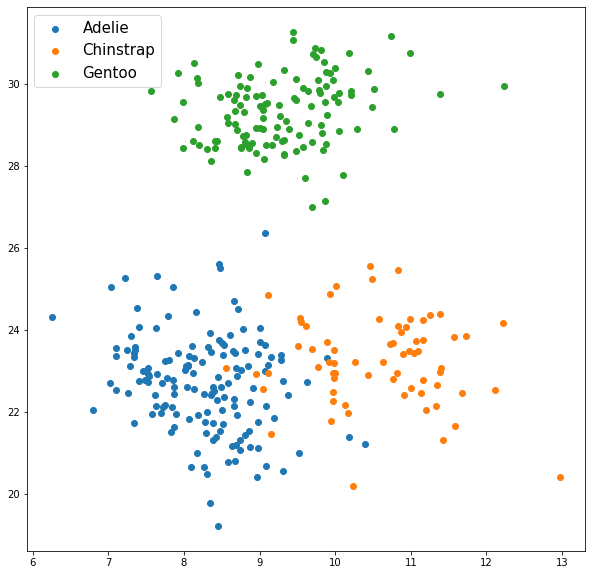

In [46]:
#project
X_red = v.T.dot(X)

# plot projected points
plt.figure(figsize=(10,10)) 
species = np.unique(y)

for i in range(len(species)):
    plt.scatter(X_red[0,y==species[i]],X_red[1,y==species[i]], label=species[i ])
    plt.legend(fontsize=15)

***

### Problem 5

In [47]:
# load the data (the files 'faces.npy' and 'face_expressions.npy' are on the Moodle site, Applications section)
X = np.load('faces.npy')
y = np.load('face_expressions.npy')

In [48]:
X.shape

(165, 4800)

Each row of the matrix X is a 60x80 pixels grayscale image. 

(-0.5, 79.5, 59.5, -0.5)

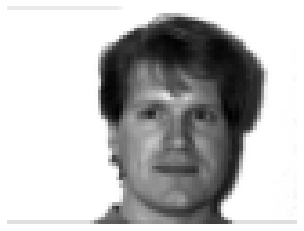

In [49]:
plt.imshow(X[0].reshape(60,80),cmap='gray')
plt.axis(False)

There are 165 grayscale images of 15 individuals. There are 11 images per subject, one per different facial expression or configuration: center-light, w/glasses, happy, left-light, w/no glasses, normal, right-light, sad, sleepy, surprised, and wink.

------------------
   INDIVIDUAL 0
------------------


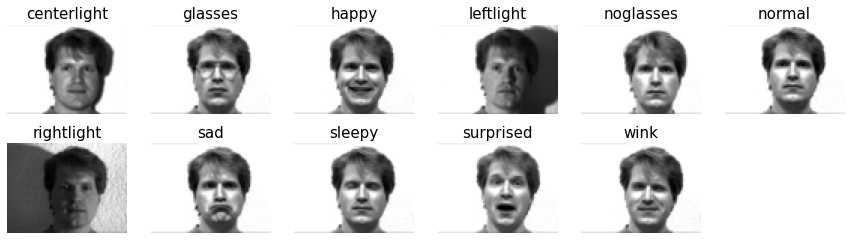

In [51]:
expressions = ['centerlight','glasses','happy','leftlight','noglasses','normal','rightlight','sad','sleepy','surprised','wink']
for individual in range(1):
    print('------------------')
    print('   INDIVIDUAL '+str(individual))
    print('------------------')
    plt.figure(figsize=(15,4))
    for j in range(11):
        face = X[11*individual+j].reshape(60,80)
        plt.subplot(2, 6,j+1)
        plt.imshow(face,cmap='gray')
        plt.axis('off')
        plt.title(y[11*individual+j], fontsize=15)
    plt.show()

We are going to use Linear Discriminant Analysis (LDA) to find the 2-dimensional subspace (plane) consisting of the directions which maximize the separation between classes.
Rather than using our `lda` function, we are going to use [scikit-learn](https://scikit-learn.org/stable/index.html) [`LinearDiscriminantAnalysis`](https://scikit-learn.org/stable/modules/lda_qda.html#lda-qda) function.

In [53]:
# import the Linear Discriminant Analysis function from sci-kit learn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# instantiate the function
lda = LinearDiscriminantAnalysis(n_components=2)
# project the data onto R2
P = lda.fit_transform(X,y)

Plot the projected data points. Color each point according to its class (face expression).

In [57]:
P=P.T

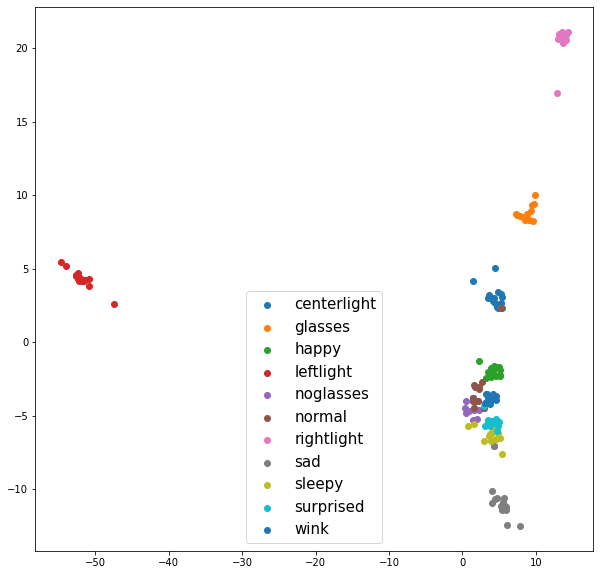

In [58]:
# plot projected points
plt.figure(figsize=(10,10)) 
classes = np.unique(y)

for i in range(len(classes)):
    plt.scatter(P[0,y==classes[i]],P[1,y==classes[i]], label=classes[i ])
    plt.legend(fontsize=15)

There we go! A fun little plot. Are the classes well-separated? maybe. I wonder if there would be more interesting results if we did not have the left/right/center light classes. 